# ASIC temporal aggregation preview: 8h vs 16h

This notebook reads saved artifacts only. It does not retrain models.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

EIGHT_HOUR_EVAL_ROOT = Path('/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/evaluation/asic/baselines/primary_medians')
SIXTEEN_HOUR_EVAL_ROOT = Path('/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/temporal_preview/asic/aggregation_16h/evaluation/asic/baselines/primary_medians')
COMPARISON_TABLE_PATH = Path('/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/temporal_preview/asic/aggregation_16h/comparison/aggregation_comparison_metrics.csv')
NOTE_PATH = Path('/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/temporal_preview/asic/aggregation_16h/comparison/preview_note.md')
FIGURE_PATHS = [Path(path) for path in ['/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/temporal_preview/asic/aggregation_16h/comparison/logistic_regression_24h_reliability_8h_vs_16h.png', '/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/temporal_preview/asic/aggregation_16h/comparison/logistic_regression_24h_mortality_vs_risk_8h_vs_16h.png', '/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/temporal_preview/asic/aggregation_16h/comparison/xgboost_24h_reliability_8h_vs_16h.png', '/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/temporal_preview/asic/aggregation_16h/comparison/xgboost_24h_mortality_vs_risk_8h_vs_16h.png']]

for path in [EIGHT_HOUR_EVAL_ROOT, SIXTEEN_HOUR_EVAL_ROOT, COMPARISON_TABLE_PATH, NOTE_PATH]:
    print(path, 'exists=', path.exists())


/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/evaluation/asic/baselines/primary_medians exists= True
/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/temporal_preview/asic/aggregation_16h/evaluation/asic/baselines/primary_medians exists= True
/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/temporal_preview/asic/aggregation_16h/comparison/aggregation_comparison_metrics.csv exists= True
/Users/joanameyer/repository/1-mortality-decomposition/artifacts/chapter1/temporal_preview/asic/aggregation_16h/comparison/preview_note.md exists= True


In [2]:
def load_reporting_metrics(evaluation_root: Path, aggregation: str) -> pd.DataFrame:
    reporting = pd.read_csv(evaluation_root / 'reporting_split_summary.csv')
    combined = pd.read_csv(evaluation_root / 'combined_metrics.csv')
    metric_columns = [
        'model_name', 'horizon_h', 'split', 'sample_count', 'event_count', 'non_event_count',
        'event_rate', 'auroc', 'auprc', 'calibration_intercept', 'calibration_slope',
        'brier_score'
    ]
    merged = reporting.merge(
        combined[metric_columns],
        left_on=['model_name', 'horizon_h', 'selected_split'],
        right_on=['model_name', 'horizon_h', 'split'],
        how='left',
        suffixes=('_selected', ''),
    )
    merged['aggregation'] = aggregation
    return merged[['model_name', 'horizon_h', 'aggregation', 'selected_split', 'sample_count', 'event_count', 'auroc', 'auprc', 'calibration_intercept', 'calibration_slope', 'brier_score']]

comparison = pd.concat(
    [
        load_reporting_metrics(EIGHT_HOUR_EVAL_ROOT, '8h'),
        load_reporting_metrics(SIXTEEN_HOUR_EVAL_ROOT, '16h'),
    ],
    ignore_index=True,
)
comparison = comparison.sort_values(['model_name', 'horizon_h', 'aggregation']).reset_index(drop=True)
comparison


,model_name,horizon_h,aggregation,selected_split,sample_count,event_count,auroc,auprc,calibration_intercept,calibration_slope,brier_score
0,logistic_regression,8,16h,train,387,6,0.881015,0.337664,1.045695,1.319701,0.012655
1,logistic_regression,8,8h,validation,244,2,0.419421,0.011898,-5.880084,-0.170403,0.011678
2,logistic_regression,16,16h,validation,121,2,0.592437,0.035548,-3.354688,0.162806,0.019627
3,logistic_regression,16,8h,validation,243,4,0.654812,0.058796,-2.392905,0.387449,0.017934
4,logistic_regression,24,16h,validation,120,2,0.694915,0.114286,-2.377861,0.544949,0.024630
5,logistic_regression,24,8h,validation,242,6,0.740819,0.115801,-1.476574,0.630244,0.025735
6,logistic_regression,48,16h,validation,119,6,0.582596,0.071013,-2.550171,0.126862,0.073643
7,logistic_regression,48,8h,validation,239,12,0.569750,0.085797,-2.227094,0.235836,0.056070
8,logistic_regression,72,16h,validation,117,8,0.614679,0.094217,-2.125618,0.189500,0.100321
9,logistic_regression,72,8h,validation,236,18,0.654434,0.142132,-1.597962,0.340322,0.082065


In [3]:
saved_comparison = pd.read_csv(COMPARISON_TABLE_PATH)
saved_comparison


,model_name,horizon_h,aggregation,selected_split,selected_split_evaluable,selection_reason,sample_count,event_count,non_event_count,event_rate,auroc,auprc,calibration_intercept,calibration_slope,brier_score,binary_metrics_evaluable,finite_prediction_count,metric_notes
0,logistic_regression,8,16h,train,True,first_binary_evaluable_split_in_priority_order,387,6,381,0.015504,0.881015,0.337664,1.045695,1.319701,0.012655,True,387,NaN
1,logistic_regression,8,8h,validation,True,first_binary_evaluable_split_in_priority_order,244,2,242,0.008197,0.419421,0.011898,-5.880084,-0.170403,0.011678,True,244,NaN
2,logistic_regression,16,16h,validation,True,first_binary_evaluable_split_in_priority_order,121,2,119,0.016529,0.592437,0.035548,-3.354688,0.162806,0.019627,True,121,NaN
3,logistic_regression,16,8h,validation,True,first_binary_evaluable_split_in_priority_order,243,4,239,0.016461,0.654812,0.058796,-2.392905,0.387449,0.017934,True,243,NaN
4,logistic_regression,24,16h,validation,True,first_binary_evaluable_split_in_priority_order,120,2,118,0.016667,0.694915,0.114286,-2.377861,0.544949,0.024630,True,120,NaN
5,logistic_regression,24,8h,validation,True,first_binary_evaluable_split_in_priority_order,242,6,236,0.024793,0.740819,0.115801,-1.476574,0.630244,0.025735,True,242,NaN
6,logistic_regression,48,16h,validation,True,first_binary_evaluable_split_in_priority_order,119,6,113,0.050420,0.582596,0.071013,-2.550171,0.126862,0.073643,True,119,NaN
7,logistic_regression,48,8h,validation,True,first_binary_evaluable_split_in_priority_order,239,12,227,0.050209,0.569750,0.085797,-2.227094,0.235836,0.056070,True,239,NaN
8,logistic_regression,72,16h,validation,True,first_binary_evaluable_split_in_priority_order,117,8,109,0.068376,0.614679,0.094217,-2.125618,0.189500,0.100321,True,117,NaN
9,logistic_regression,72,8h,validation,True,first_binary_evaluable_split_in_priority_order,236,18,218,0.076271,0.654434,0.142132,-1.597962,0.340322,0.082065,True,236,NaN


In [4]:
print(NOTE_PATH.read_text())


# ASIC Temporal Aggregation Preview: 8h vs 16h

Across the comparable non-train holdout pairs, the 16h preview looks broadly similar rather than obviously unstable. On its own, it does not suggest that the Chapter 1 signal is an artifact of the 8h aggregation choice.
Calibration did not show an obvious across-the-board collapse.
The 24h mortality-vs-risk comparison should be read cautiously because at least one curve is sparse or visibly reshaped.

Comparable holdout pairs used for the compact stability summary: Logistic Regression 16h, Logistic Regression 24h, Logistic Regression 48h, Logistic Regression 72h, XGBoost 16h, XGBoost 24h, XGBoost 48h, XGBoost 72h.
Maximum absolute AUROC delta across comparable holdout pairs: 0.086.
Maximum absolute AUPRC delta across comparable holdout pairs: 0.048.
Maximum absolute Brier-score delta across comparable holdout pairs: 0.018.

Primary 24h comparison:
- Logistic Regression 24h: AUROC 0.741 -> 0.695, AUPRC 0.116 -> 0.114, slope 0.630 -> 0.545.


## logistic_regression_24h_reliability_8h_vs_16h.png


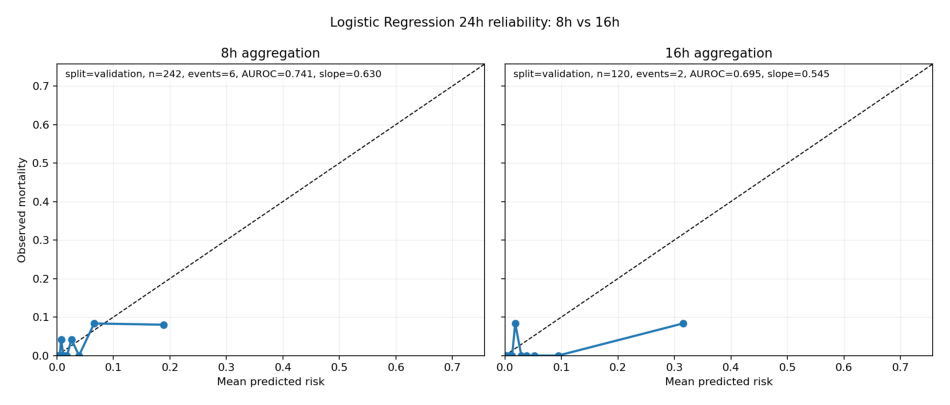


## logistic_regression_24h_mortality_vs_risk_8h_vs_16h.png


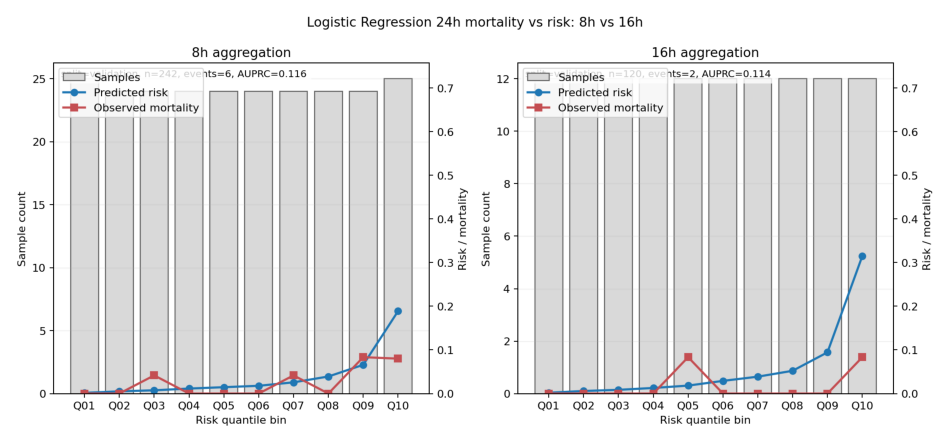


## xgboost_24h_reliability_8h_vs_16h.png


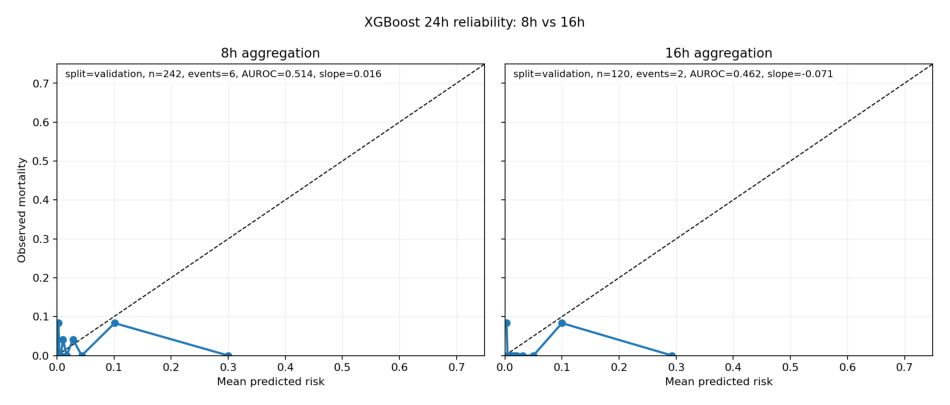


## xgboost_24h_mortality_vs_risk_8h_vs_16h.png


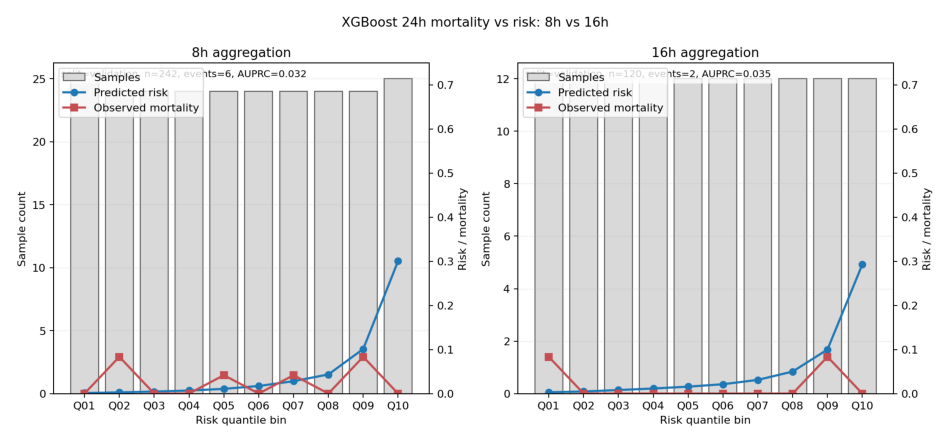

In [5]:
for figure_path in FIGURE_PATHS:
    print(f'\n## {figure_path.name}')
    image = plt.imread(figure_path)
    plt.figure(figsize=(12, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.show()
